# Customer satisfaction using ML

**Import Library**

In [ ]:
import pandas as p
import numpy as np
import seaborn as sns
import warnings
warnings.simplefilter("ignore")
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use("ggplot")

import matplotlib as mpl
import plotly.express as px
from plotly.subplots import make_subplots

%matplotlib inline
import plotly.graph_objects as go
import plotly.express as px
color_scheme = px.colors.qualitative.Pastel

## Import Dataset to Model

In [ ]:
df = pd.read_csv("DataSetN.csv")
df.head()

,useOnlineTransaction,useOnlineTransaction.1,WhichOperators,SingleOperatorRating,operatorRating1,operatorRating2,operatorRating1.1,operatorRating2.2,operatorRating3,operatorRating1.1.1,operatorRating2.2.2,operatorRating3.3.3,operatorRating4.4.4,Satisfaction,classlabel
0,Yes,3.0,Upay,NaN,NaN,NaN,3.0,2.0,10.0,NaN,NaN,9.0,6.0,5.000000,average
1,Yes,3.0,"Bkash, Nagad, Rocket",NaN,NaN,NaN,7.0,8.0,8.0,NaN,NaN,NaN,6.0,7.666667,good
2,Yes,3.0,Nagad,NaN,NaN,NaN,6.0,4.0,1.0,NaN,NaN,NaN,NaN,3.666667,average
3,Yes,2.0,Rocket,NaN,5.0,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.500000,average
4,Yes,3.0,Bkash,NaN,NaN,NaN,6.0,2.0,9.0,NaN,7.0,NaN,NaN,5.666667,average


## Data Pre-poccessing

**Null Value Check**

In [ ]:
df.isna().sum()

,0
useOnlineTransaction,2
useOnlineTransaction.1,865
WhichOperators,870
SingleOperatorRating,6168
operatorRating1,7825
operatorRating2,7813
operatorRating1.1,8204
operatorRating2.2,8195
operatorRating3,8190
operatorRating1.1.1,9316


In [ ]:
df.describe()

,useOnlineTransaction.1,SingleOperatorRating,operatorRating1,operatorRating2,operatorRating1.1,operatorRating2.2,operatorRating3,operatorRating1.1.1,operatorRating2.2.2,operatorRating3.3.3,operatorRating4.4.4,Satisfaction
count,9371.000000,4068.000000,2411.000000,2423.000000,2032.000000,2041.000000,2046.000000,920.000000,918.000000,919.000000,924.000000,9372.000000
mean,1.971294,6.957473,5.243882,5.584400,6.184547,5.839784,6.814761,5.645652,5.592048,6.848749,6.080087,6.326220
std,1.016685,2.497289,2.525932,2.658555,2.473871,2.608114,2.601560,2.703418,2.581596,2.758622,2.693854,2.359795
min,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,2.000000,0.000000
25%,1.000000,6.000000,3.000000,3.000000,5.000000,4.000000,5.000000,4.000000,3.000000,5.000000,4.000000,4.666667
50%,2.000000,8.000000,5.000000,5.000000,6.000000,5.000000,7.000000,6.000000,5.000000,7.000000,6.000000,7.000000
75%,3.000000,9.000000,8.000000,8.000000,8.000000,8.000000,9.000000,8.000000,8.000000,10.000000,8.000000,8.000000
max,7.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000


In [ ]:
df.shape

(10236, 15)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10236 entries, 0 to 10235
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   useOnlineTransaction    10234 non-null  object 
 1   useOnlineTransaction.1  9371 non-null   float64
 2   WhichOperators          9366 non-null   object 
 3   SingleOperatorRating    4068 non-null   float64
 4   operatorRating1         2411 non-null   float64
 5   operatorRating2         2423 non-null   float64
 6   operatorRating1.1       2032 non-null   float64
 7   operatorRating2.2       2041 non-null   float64
 8   operatorRating3         2046 non-null   float64
 9   operatorRating1.1.1     920 non-null    float64
 10  operatorRating2.2.2     918 non-null    float64
 11  operatorRating3.3.3     919 non-null    float64
 12  operatorRating4.4.4     924 non-null    float64
 13  Satisfaction            9372 non-null   float64
 14  classlabel              10224 non-null

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
useOnlineTransaction.1,9371.0,1.971294,1.016685,0.0,1.000000,2.0,3.0,7.0
SingleOperatorRating,4068.0,6.957473,2.497289,1.0,6.000000,8.0,9.0,10.0
operatorRating1,2411.0,5.243882,2.525932,1.0,3.000000,5.0,8.0,10.0
operatorRating2,2423.0,5.584400,2.658555,1.0,3.000000,5.0,8.0,10.0
operatorRating1.1,2032.0,6.184547,2.473871,1.0,5.000000,6.0,8.0,10.0
operatorRating2.2,2041.0,5.839784,2.608114,1.0,4.000000,5.0,8.0,10.0
operatorRating3,2046.0,6.814761,2.601560,1.0,5.000000,7.0,9.0,10.0
operatorRating1.1.1,920.0,5.645652,2.703418,1.0,4.000000,6.0,8.0,10.0
operatorRating2.2.2,918.0,5.592048,2.581596,1.0,3.000000,5.0,8.0,10.0
operatorRating3.3.3,919.0,6.848749,2.758622,2.0,5.000000,7.0,10.0,10.0


In [ ]:
df["useOnlineTransaction"].value_counts()

,count
useOnlineTransaction,
Yes,9366
No,868


<Axes: ylabel='count'>

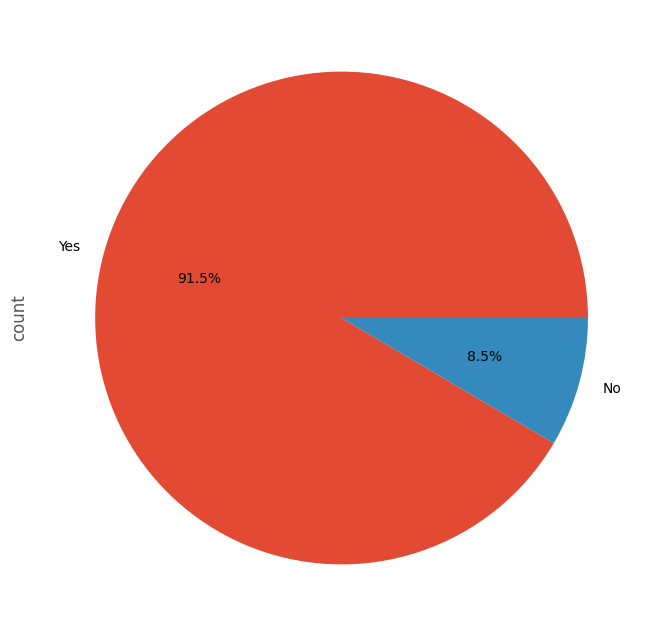

In [ ]:
plt.figure(figsize=(12,8))
df['useOnlineTransaction'].value_counts().plot.pie(autopct='%1.1f%%')

In [ ]:
def p_bar_plot (x, y, x_axis_title, y_axis_title, title):
  fig = px.bar(x = x, y = y, color = x, text = y, color_discrete_sequence = color_scheme, template = 'simple_white')
  fig.update_layout(xaxis_title = x_axis_title, yaxis_title= y_axis_title, title = title, font = dict(size=17, family= "Franklin Gothic"))
  fig.update_traces(width= 0.5)
  fig.show()

def p_pie_plot (series, title) :
  fig = px.pie(values=series.values, names=series. index, color_discrete_sequence=color_scheme, title= title, template= 'simple_white')
  fig.update_traces(textinfo= 'label+percent+value', textfont_size= 20,
                    marker=dict(line=dict(color= '#100000', width= 0.2)))
  fig.data[0].marker.line.width = 1
  fig.update_layout(font=dict(size=20, family="Franklin Gothic"))
  fig.show()

In [ ]:
df['useOnlineTransaction'].value_counts()

,count
useOnlineTransaction,
Yes,9366
No,868


<Axes: ylabel='count'>

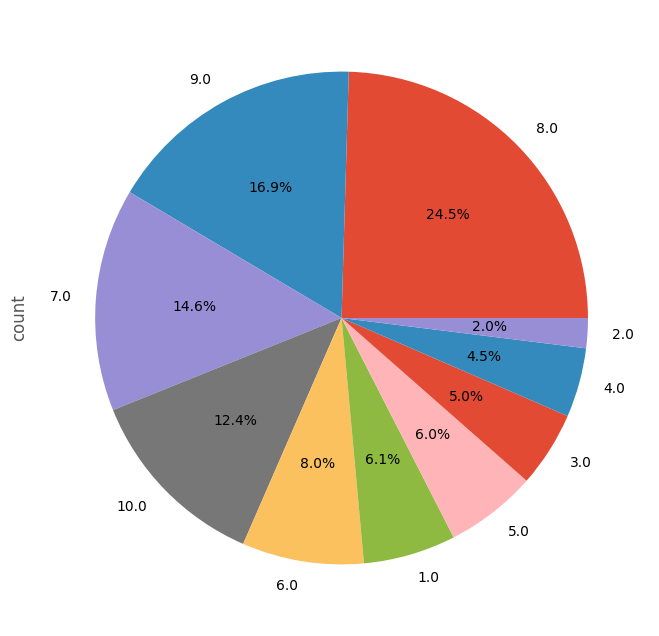

In [ ]:
plt.figure(figsize=(12,8))
df['SingleOperatorRating'].value_counts().plot.pie(autopct='%1.1f%%')

In [ ]:
plt.figure(figsize=(12,8))
df['operatorRating1'].value_counts().plot.pie(autopct='%1.1f%%')

In [ ]:
satisfaction = df['Satisfaction'].value_counts().sort_index()
p_bar_plot(satisfaction.index, satisfaction.values, 'Satisfaction', "Count", "Satisfaction Graph")

In [ ]:
df['classlabel'].value_counts()

In [ ]:
df.drop_duplicates(inplace=True)
df.isnull().sum()

,0
useOnlineTransaction,2
useOnlineTransaction.1,8
WhichOperators,9
SingleOperatorRating,218
operatorRating1,220
operatorRating2,208
operatorRating1.1,227
operatorRating2.2,218
operatorRating3,213
operatorRating1.1.1,257


In [ ]:
x = df.drop(['classlabel'], axis=1)

In [ ]:
x

In [ ]:
y = df['classlabel']

In [ ]:
y

In [ ]:
df = df[df['classlabel'] != 'classlabel']
df.dropna(subset=['classlabel'], inplace=True)
df['classlabel'].value_counts()

,count
classlabel,
good,156
average,123
below average,44


## Features Correlation

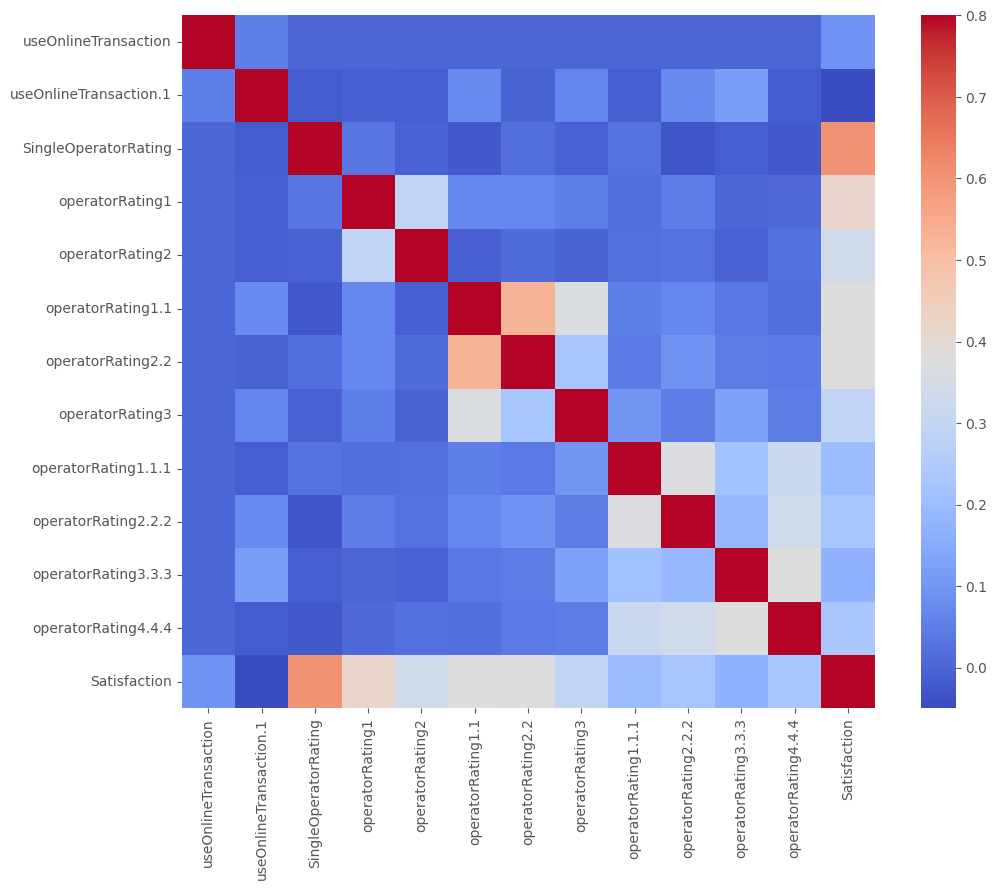

In [ ]:
corrmat = X.corr()
plt.figure(figsize=(12, 9))
sns.heatmap(corrmat, vmax=.8, square=True, cmap="coolwarm")
plt.show()

In [ ]:
df_operators = df.copy()
df_operators.dropna(subset=['WhichOperators'], inplace=True)

operators_series = df_operators['WhichOperators'].str.split(', ', expand=True).stack()
operators_series = operators_series.reset_index(level=1, drop=True)

operator_df = operators_series.to_frame(name='Operator')
operator_df['Operator'] = operator_df['Operator'].str.strip()

merged_df = pd.merge(operator_df, df['classlabel'], left_index=True, right_index=True)

filtered_operators = ['Bkash', 'Nagad', 'Rocket']
merged_df = merged_df[merged_df['Operator'].isin(filtered_operators)]

print("Shape of merged_df:", merged_df.shape)
print("First 5 rows of merged_df:")
print(merged_df.head())

Shape of merged_df: (452, 2)
First 5 rows of merged_df:
  Operator classlabel
1    Bkash       good
1    Nagad       good
1   Rocket       good
2    Nagad    average
3   Rocket    average


In [ ]:
sentiment_counts = merged_df.groupby(['Operator', 'classlabel']).size().unstack(fill_value=0)
print("Sentiment counts per operator:")
print(sentiment_counts)

Sentiment counts per operator:
classlabel  average  below average  good
Operator                                
Bkash            67             26    92
Nagad            75             20    75
Rocket           34             11    52


In [ ]:
sentiment_counts_reset = sentiment_counts.reset_index()
sentiment_melted = sentiment_counts_reset.melt(id_vars=['Operator'], var_name='Sentiment', value_name='Count')

fig = px.bar(
    sentiment_melted,
    x='Operator',
    y='Count',
    color='Sentiment',
    barmode='group',
    title='Sentiment Distribution per Operator',
    labels={'Operator': 'Operator', 'Count': 'Number of Sentiments'},
    color_discrete_sequence=px.colors.qualitative.Pastel
)
fig.update_layout(xaxis_title='Operator', yaxis_title='Number of Sentiments', title_x=0.5)
fig.show()

In [ ]:
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
# Exclude 'Satisfaction' from direct imputation if it's considered a target or special case, but the instruction is general for numerical columns.
# However, 'Satisfaction' is a primary feature, and it might be the target variable based on 'classlabel'.
# Let's impute all numerical columns except for 'classlabel', as it's not a numerical column.

for col in numerical_cols:
    if df[col].isnull().any():
        mean_value = df[col].mean()
        df[col].fillna(mean_value, inplace=True)

print("Missing values after numerical imputation:")
print(df[numerical_cols].isnull().sum())

Missing values after numerical imputation:
useOnlineTransaction.1    0
SingleOperatorRating      0
operatorRating1           0
operatorRating2           0
operatorRating1.1         0
operatorRating2.2         0
operatorRating3           0
operatorRating1.1.1       0
operatorRating2.2.2       0
operatorRating3.3.3       0
operatorRating4.4.4       0
Satisfaction              0
dtype: int64


In [ ]:
df['useOnlineTransaction'] = df['useOnlineTransaction'].map({'Yes': 1, 'No': 0})
mode_value = df['useOnlineTransaction'].mode()[0]
df['useOnlineTransaction'].fillna(mode_value, inplace=True)
print("Missing values in 'useOnlineTransaction' after encoding and imputation:")
print(df['useOnlineTransaction'].isnull().sum())

Missing values in 'useOnlineTransaction' after encoding and imputation:
0


In [ ]:
df.drop('WhichOperators', axis=1, inplace=True)
print("Columns after dropping 'WhichOperators':")
print(df.columns)

Columns after dropping 'WhichOperators':
Index(['useOnlineTransaction', 'useOnlineTransaction.1',
       'SingleOperatorRating', 'operatorRating1', 'operatorRating2',
       'operatorRating1.1', 'operatorRating2.2', 'operatorRating3',
       'operatorRating1.1.1', 'operatorRating2.2.2', 'operatorRating3.3.3',
       'operatorRating4.4.4', 'Satisfaction', 'classlabel'],
      dtype='object')


## Lebel encoding

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['classlabel'] = le.fit_transform(df['classlabel'])

print("Encoded 'classlabel' value counts:")
print(df['classlabel'].value_counts())
print("Original label mapping:")
for i, label in enumerate(le.classes_):
    print(f"{label}: {i}")

Encoded 'classlabel' value counts:
classlabel
2    156
0    123
1     44
Name: count, dtype: int64
Original label mapping:
average: 0
below average: 1
good: 2


In [ ]:
X = df.drop('classlabel', axis=1)
y = df['classlabel']

print("Shape of X (features):", X.shape)
print("Shape of y (target):", y.shape)

Shape of X (features): (323, 13)
Shape of y (target): (323,)


## Data set Splitting 20% 80% Ratio

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (258, 13)
Shape of X_test: (65, 13)
Shape of y_train: (258,)
Shape of y_test: (65,)


## Model Construction

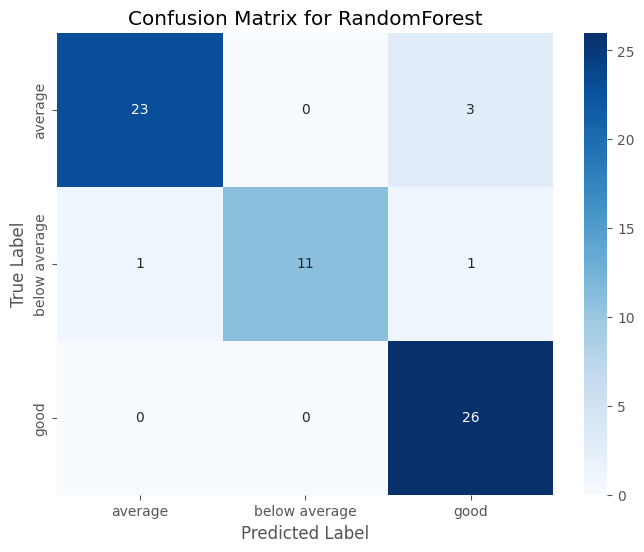

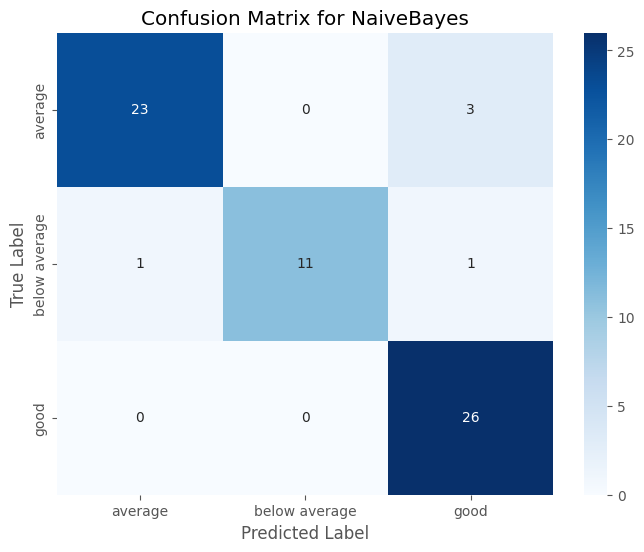

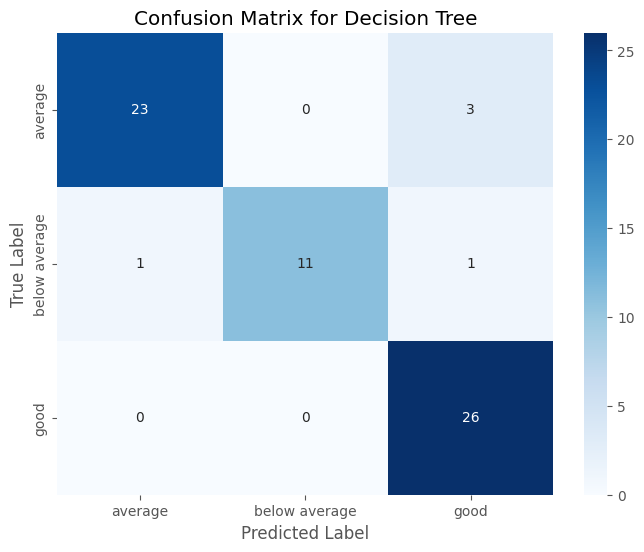

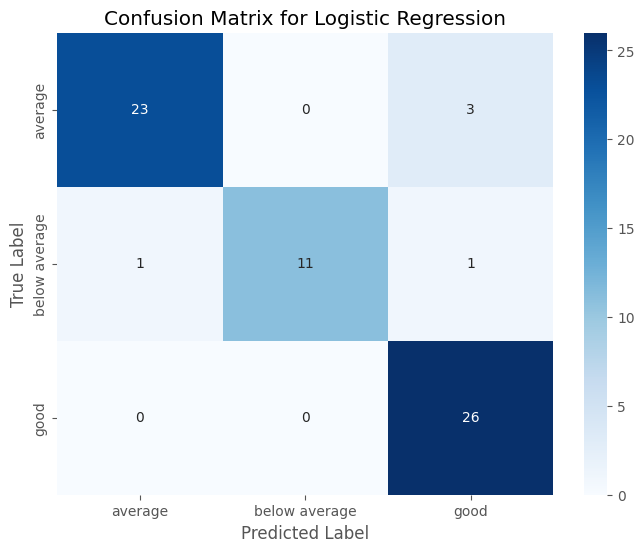

            Classifier  Accuracy  Precision    Recall  F1 Score  \
0         RandomForest  0.969231   0.970370  0.969231  0.968239   
1           NaiveBayes  0.753846   0.847619  0.753846  0.748477   
2        Decision Tree  0.984615   0.985185  0.984615  0.984453   
3  Logistic Regression  0.923077   0.930000  0.923077  0.922762   

   Training Time  Testing Time  
0       0.151443      0.008083  
1       0.003444      0.002297  
2       0.004839      0.002455  
3       0.146874      0.001666  


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import time
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

# Assuming X_train, Y_train, X_test, Y_test are already defined

# Define classifiers
classifiers = {
    "RandomForest": RandomForestClassifier(),


    "NaiveBayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(),
    "Logistic Regression": LogisticRegression(max_iter=10000)
}

# Prepare table to store results
results = []

# Loop through classifiers and compute metrics
for name, clf in classifiers.items():
    # Train the model and record training time
    start_train = time.time()
    clf.fit(X_train, y_train)
    end_train = time.time()

        # Predict and show testing time
    start_test = time.time()
    y_pred = clf.predict(X_test)
    end_test = time.time()

    # Compute metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=1)
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    training_time = end_train - start_train
    testing_time = end_test - start_test


    # Compute confusion matrix
    conf_matrix = confusion_matrix(y_test, y_pred)

    # Append the results to the list
    results.append({
        "Classifier": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "Training Time": training_time,
        "Testing Time": testing_time,
        "Confusion Matrix": conf_matrix
    })

    # Graph confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f"Confusion Matrix for {name}")
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

# Convert results to DataFrame
results_df = pd.DataFrame(results).drop(columns=['Confusion Matrix'])
print(results_df)

In [ ]:
results_df

,Classifier,Accuracy,Precision,Recall,F1 Score,Training Time,Testing Time
0,RandomForest,0.969231,0.970370,0.969231,0.968239,0.151443,0.008083
1,NaiveBayes,0.753846,0.847619,0.753846,0.748477,0.003444,0.002297
2,Decision Tree,0.984615,0.985185,0.984615,0.984453,0.004839,0.002455
3,Logistic Regression,0.923077,0.930000,0.923077,0.922762,0.146874,0.001666
